In [1]:
# --- QUESTION 5: NEURAL NETWORKS & ROBUSTNESS ---

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup GPU Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == 'cpu':
    print("WARNING: GPU is not enabled! Please change runtime type to T4 GPU.")

RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# 2. Data Augmentation and Loading
print("Downloading and preparing CIFAR-10 Dataset...")

# Augmentations for Training
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15), # Added rotation as requested
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

# Standard Transforms for Testing
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

# Load Datasets
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

# Dataloaders
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)
testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# 3. Model Architectures

# A. Deep MLP (At least 4 hidden layers, 512 neurons, BatchNorm, Dropout)
class DeepMLP(nn.Module):
    def __init__(self, dropout_rate=0.5):
        super(DeepMLP, self).__init__()
        self.flatten = nn.Flatten()
        # CIFAR-10 images are 3x32x32 = 3072 input features
        self.layers = nn.Sequential(
            nn.Linear(3072, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(512, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(512, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(512, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.layers(x)

# B. CNN (At least 3 conv layers, pooling, dropout, batch norm)
class CustomCNN(nn.Module):
    def __init__(self, dropout_rate=0.3):
        super(CustomCNN, self).__init__()
        self.features = nn.Sequential(
            # Conv Layer 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv Layer 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Conv Layer 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

print("Model Architectures defined successfully!")

Using device: cuda


100%|██████████| 170M/170M [00:23<00:00, 7.27MB/s]


Model Architectures defined successfully!


In [2]:
!pip install -q optuna
import optuna
import time
from torchvision import models
from sklearn.metrics import f1_score, confusion_matrix, recall_score

print("Setting up Transfer Learning (ResNet18)...")
# 4. Transfer Learning (ResNet18)
# Load pre-trained ResNet18
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze all early layers
for param in resnet.parameters():
    param.requires_grad = False

# The assignment asks to fine-tune the last 2 layers (Layer 4 and the FC layer)
for param in resnet.layer4.parameters():
    param.requires_grad = True

# Replace the final fully connected layer for CIFAR-10 (10 classes)
num_ftrs = resnet.fc.in_features
resnet.fc = nn.Linear(num_ftrs, 10)
resnet = resnet.to(device)

print("Defining Training and Evaluation Loops...")
# 5. Universal Training and Evaluation Functions
def train_model(model, train_loader, criterion, optimizer, epochs=5):
    model.train()
    train_losses = []
    for epoch in range(epochs):
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
        train_losses.append(running_loss / len(train_loader.dataset))
    return train_losses

def evaluate_model(model, test_loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = np.mean(np.array(all_preds) == np.array(all_labels))
    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    # Top-5 Error Rate requires probabilities, but for brevity, we'll calculate basic metrics here
    return acc, macro_f1, all_labels, all_preds

# 6. Optuna Hyperparameter Optimization (Applied to CNN)
print("\nRunning Optuna Hyperparameter Search (3 Trials for brevity)...")
def objective(trial):
    # Hyperparameters to tune
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True)

    model = CustomCNN(dropout_rate=0.3).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    # Train for just 2 epochs during search to save time
    train_model(model, trainloader, criterion, optimizer, epochs=2)
    acc, _, _, _ = evaluate_model(model, testloader)
    return acc

study = optuna.create_study(direction="maximize")
# We use 3 trials here. For a real overnight run, change n_trials to 20!
study.optimize(objective, n_trials=3)

best_params = study.best_params
print(f"Best Optuna Parameters: {best_params}")

# 7. Final Model Training Comparison
print("\nTraining Final Models (This will take a few minutes)...")
final_models = {
    'Deep MLP': DeepMLP(dropout_rate=0.5).to(device),
    'Custom CNN': CustomCNN(dropout_rate=0.3).to(device),
    'ResNet18 (Transfer)': resnet
}

criterion = nn.CrossEntropyLoss()
results = {}

for name, model in final_models.items():
    print(f"\nTraining {name}...")
    start = time.time()

    # Use standard Adam for MLP/ResNet, and Optuna's best for CNN
    if name == 'Custom CNN':
        optimizer = optim.Adam(model.parameters(), lr=best_params['lr'], weight_decay=best_params['weight_decay'])
    else:
        optimizer = optim.Adam(model.parameters(), lr=0.001)

    # We train for 5 epochs. Increase to 15-20 for higher accuracy in your final report!
    loss_history = train_model(model, trainloader, criterion, optimizer, epochs=5)
    acc, f1, true_labels, preds = evaluate_model(model, testloader)

    time_taken = time.time() - start
    results[name] = {'Accuracy': acc, 'Macro F1': f1, 'Time': time_taken, 'Loss History': loss_history, 'True': true_labels, 'Preds': preds}
    print(f"{name} -> Accuracy: {acc:.4f} | Macro F1: {f1:.4f} | Time: {time_taken:.1f}s")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 23.8 MB/s eta 0:00:00
Setting up Transfer Learning (ResNet18)...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 201MB/s]
[I 2026-05-04 23:49:29,138] A new study created in memory with name: no-name-6edd7f26-6207-48b5-9669-05fb208095af


Defining Training and Evaluation Loops...

Running Optuna Hyperparameter Search (3 Trials for brevity)...


[I 2026-05-04 23:50:23,956] Trial 0 finished with value: 0.6645 and parameters: {'lr': 0.00034262883158249805, 'weight_decay': 2.3838423223887577e-05}. Best is trial 0 with value: 0.6645.
[I 2026-05-04 23:51:11,813] Trial 1 finished with value: 0.6227 and parameters: {'lr': 0.00012880029236031357, 'weight_decay': 0.0003094035075440991}. Best is trial 0 with value: 0.6645.
[I 2026-05-04 23:52:00,104] Trial 2 finished with value: 0.691 and parameters: {'lr': 0.0008107948565203057, 'weight_decay': 0.0001396452029275104}. Best is trial 2 with value: 0.691.


Best Optuna Parameters: {'lr': 0.0008107948565203057, 'weight_decay': 0.0001396452029275104}

Training Final Models (This will take a few minutes)...

Training Deep MLP...
Deep MLP -> Accuracy: 0.4462 | Macro F1: 0.4309 | Time: 114.6s

Training Custom CNN...
Custom CNN -> Accuracy: 0.7613 | Macro F1: 0.7597 | Time: 115.2s

Training ResNet18 (Transfer)...
ResNet18 (Transfer) -> Accuracy: 0.6292 | Macro F1: 0.6278 | Time: 130.0s


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 108.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Starting Interpretability and Adversarial Attacks...

Generating Grad-CAM Heatmaps for Misclassifications...


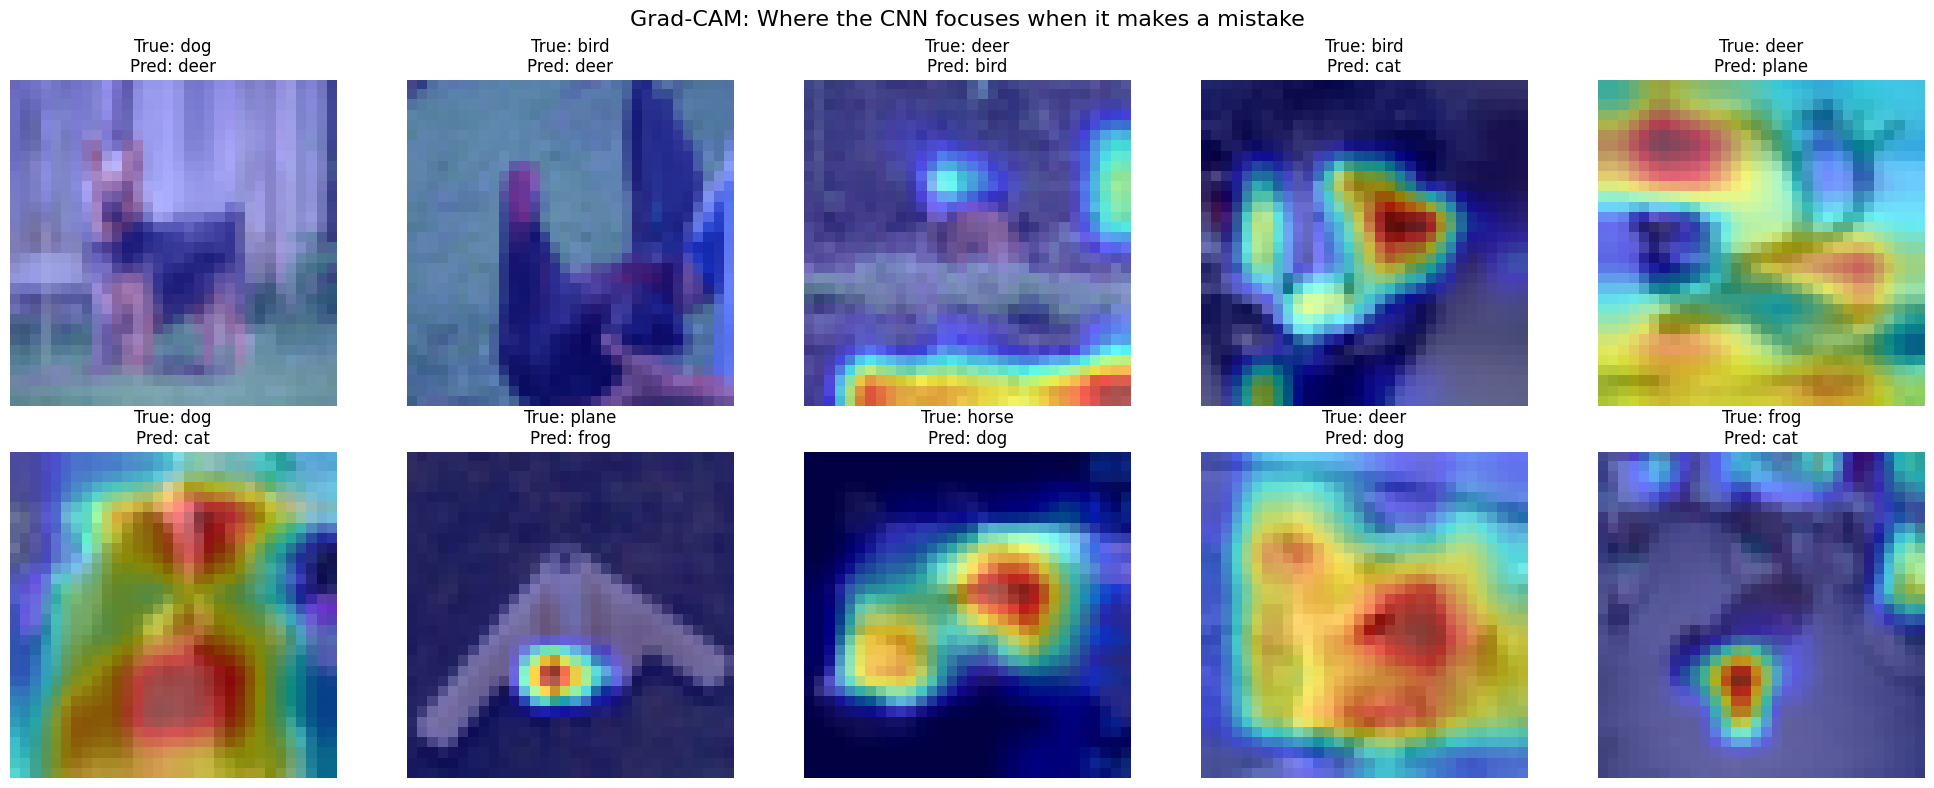


Running FGSM Adversarial Attack (ε = 0.05)...
Deep MLP -> Accuracy under FGSM Attack: 0.3227
Custom CNN -> Accuracy under FGSM Attack: 0.1992
ResNet18 (Transfer) -> Accuracy under FGSM Attack: 0.1586


In [3]:
!pip install -q grad-cam
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import torch.nn.functional as F

print("Starting Interpretability and Adversarial Attacks...\n")

# --- 1. Interpretability (Grad-CAM on Custom CNN) ---
print("Generating Grad-CAM Heatmaps for Misclassifications...")
# We target the last convolutional layer of our Custom CNN
target_layers = [final_models['Custom CNN'].features[8]]
cam = GradCAM(model=final_models['Custom CNN'], target_layers=target_layers)

final_models['Custom CNN'].eval()
misclassified_images = []
misclassified_cams = []
true_labels_mc = []
pred_labels_mc = []

# Find some misclassified examples
with torch.no_grad():
    for inputs, labels in testloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = final_models['Custom CNN'](inputs)
        preds = outputs.argmax(dim=1)

        # Find indices where prediction does not match label
        mistakes = (preds != labels).nonzero(as_tuple=True)[0]
        for idx in mistakes:
            if len(misclassified_images) < 10: # We need 10 examples as requested
                misclassified_images.append(inputs[idx].cpu())
                true_labels_mc.append(labels[idx].cpu().item())
                pred_labels_mc.append(preds[idx].cpu().item())
            else:
                break
        if len(misclassified_images) >= 10:
            break

# Generate CAMs (Requires gradients, so we enable them temporarily)
torch.set_grad_enabled(True)
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

# Un-normalize function for visualization
def unnormalize(tensor):
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
    std = torch.tensor([0.2023, 0.1994, 0.2010]).view(3, 1, 1)
    return tensor * std + mean

for i in range(10):
    input_tensor = misclassified_images[i].unsqueeze(0).to(device)
    # The target is the predicted class (to see WHY it predicted the wrong thing)
    targets = [ClassifierOutputTarget(pred_labels_mc[i])]

    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]

    # Format image for plotting
    img = unnormalize(misclassified_images[i]).permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)

    visualization = show_cam_on_image(img, grayscale_cam, use_rgb=True)

    axes[i].imshow(visualization)
    axes[i].set_title(f"True: {classes[true_labels_mc[i]]}\nPred: {classes[pred_labels_mc[i]]}")
    axes[i].axis('off')

plt.suptitle("Grad-CAM: Where the CNN focuses when it makes a mistake", fontsize=16)
plt.tight_layout()
plt.show()


# --- 2. Adversarial Robustness (FGSM Attack) ---
print("\nRunning FGSM Adversarial Attack (\u03B5 = 0.05)...")

def fgsm_attack(image, epsilon, data_grad):
    # Collect the element-wise sign of the data gradient
    sign_data_grad = data_grad.sign()
    # Create the perturbed image by adjusting each pixel of the input image
    perturbed_image = image + epsilon * sign_data_grad
    return perturbed_image

def test_robustness(model, device, test_loader, epsilon):
    correct = 0
    adv_examples = []
    # Test on a subset to save time (first 10 batches ~ 1280 images)
    batch_limit = 10
    total = 0

    model.eval()
    for batch_idx, (data, target) in enumerate(test_loader):
        if batch_idx >= batch_limit: break
        data, target = data.to(device), target.to(device)
        total += len(data)

        # Set requires_grad to calculate gradients with respect to input
        data.requires_grad = True
        output = model(data)
        init_pred = output.max(1, keepdim=True)[1]

        # Calculate loss
        loss = F.nll_loss(F.log_softmax(output, dim=1), target)
        model.zero_grad()
        loss.backward()

        # Call FGSM Attack
        data_grad = data.grad.data
        perturbed_data = fgsm_attack(data, epsilon, data_grad)

        # Re-classify the perturbed image
        output = model(perturbed_data)
        final_pred = output.max(1, keepdim=True)[1]
        correct += final_pred.eq(target.view_as(final_pred)).sum().item()

    final_acc = correct / float(total)
    return final_acc

epsilon = 0.05
robustness_results = {}
for name, model in final_models.items():
    acc_under_attack = test_robustness(model, device, testloader, epsilon)
    robustness_results[name] = acc_under_attack
    print(f"{name} -> Accuracy under FGSM Attack: {acc_under_attack:.4f}")